In [1]:
%load_ext autoreload

In [2]:
import pymc as pm
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pickle
import shutil
import numpy as np
import xarray as xr

%autoreload
import covid19_inference.covid19_inference as cov19
import utils
import plot
import model
import data_prep
import model_comparison

# Input

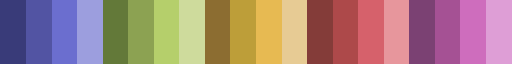

In [6]:
# colormap for plots
from matplotlib import colormaps
colormap = colormaps['tab20b']
colormap

In [3]:
# for the comparison section
limit = 6
all_indicator_combinations = utils.indicator_combinations(limit=limit)
len(all_indicator_combinations)

31

# Comparison

## LFO

In [3]:
mean, SE = model_comparison.calculate_ELPD_differences("no_indicator", "bare_model")

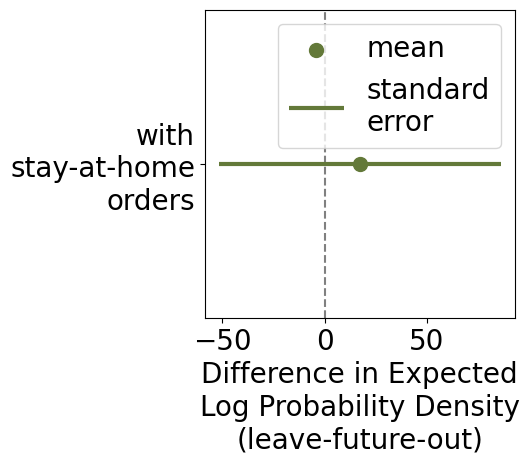

In [4]:
# plot mean and standard error of ELPD differences
# the standard error should be a horizontal line
# the mean should be a point
# for reference there is a vertical dashed line at 0
# the y axis is just one tick mark with label "with stay-at-home orders" for now

ymin = -1
ymax = 1
color = plot.colors["S"]

fig, ax = plt.subplots(figsize=(4, 4))
ax.vlines(x=0, ymin=ymin, ymax=ymax,color="grey", linestyle="--")
ax.scatter(mean, 0, s=100, color=color, label="mean")
ax.hlines(y=0, xmin=mean-SE, xmax=mean+SE, linewidth=3, color=color, label="standard\nerror")
ax.set_yticks([0])
ax.set_yticklabels(["with\nstay-at-home\norders"])
ax.set_ylim(ymin, ymax)
ax.set_xlabel("Difference in Expected\nLog Probability Density\n(leave-future-out)")
ax.legend()

In [9]:


name = "none"
# create empty dictionary with all indicator combinations as keys
elpd_dict = {}
keys = []

for indicators in all_indicator_combinations:
    indicator_tag = ""
    key = ""
    for indicator in indicators:
        indicator_tag += indicator + "_"
        key += indicator + "+"
    indicator_tag = indicator_tag[:-1]
    key = key[:-1]
    keys.append(key)

    elpd_dict[key] = read_ELPD(name, indicator_tag)
elpd_dict["none"] = read_ELPD("no_indicator", "")

In [10]:
elpd_dict

{'R': -54.38677267316869,
 'C': 21.751324188298685,
 'H': 35.55443307702967,
 'ICU': 57.92673693778689,
 'D': 35.85098286801735,
 'R+C': -259.36698891375715,
 'R+H': -252.96248138170645,
 'R+ICU': -236.71145341216058,
 'R+D': -268.3868549469911,
 'C+H': -223.89024310966337,
 'C+ICU': -227.6508841025349,
 'C+D': -223.7822466632966,
 'H+ICU': -231.27294726926672,
 'H+D': -228.88036322045852,
 'ICU+D': -234.5315847524995,
 'R+C+H': -416.98446537334956,
 'R+C+ICU': -395.97933226347385,
 'R+C+D': -419.78327979869584,
 'R+H+ICU': -415.80001797672594,
 'R+H+D': -418.16889090025836,
 'R+ICU+D': -417.1891728154159,
 'C+H+ICU': -402.0655185674599,
 'C+H+D': -405.33212041014946,
 'C+ICU+D': -406.706950793273,
 'H+ICU+D': -405.06838008087715,
 'R+C+H+ICU': -464.36533759857,
 'R+C+H+D': -466.3109707200429,
 'R+C+ICU+D': -466.49581157101545,
 'R+H+ICU+D': -465.4602964050982,
 'C+H+ICU+D': -458.3147403814097,
 'R+C+H+ICU+D': -490.5537852831869,
 'none': 60.805464136706064}

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (5,) and arg 1 with shape (6,).

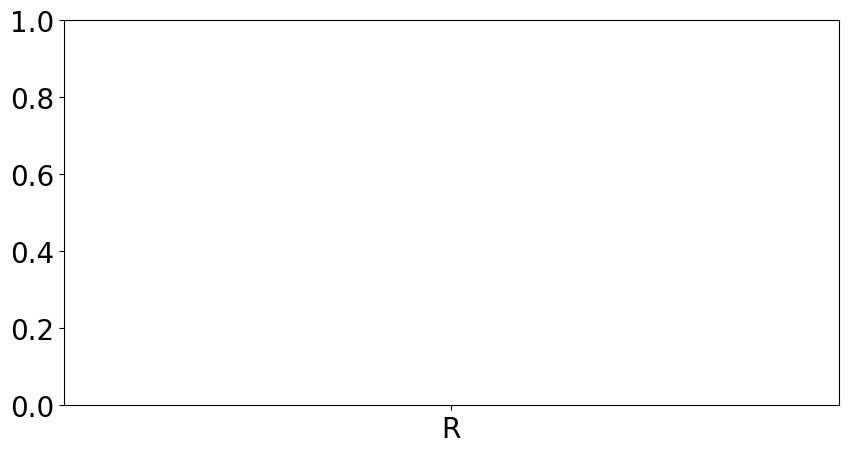

In [5]:
# plot ELPD for all indicator combinations
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(keys, trace_dict.values())
ax.set_ylabel("ELPD")


## Disease model
Given that the best performing model is the one without pandemic fatigue and with temperature:
What is the best selection of pandemic state indicators?

In [7]:
name = "none"
# create empty dictionary with all indicator combinations as keys
trace_dict = {}
keys = []

for indicators in all_indicator_combinations:
    indicator_tag = ""
    key = ""
    for indicator in indicators:
        indicator_tag += indicator + "_"
        key += indicator + "+"
    indicator_tag = indicator_tag[:-1]
    key = key[:-1]
    keys.append(key)

    trace_dict[key] = utils.load_trace(name, indicator_tag)
trace_dict["none"] = utils.load_trace("no_indicator", "")

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/

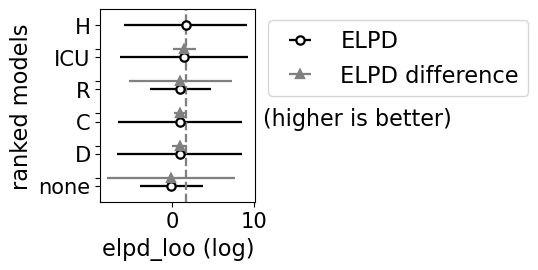

In [15]:
# compare plot with subplot for each indicator comibination, comparing the linear and sigmoid models
height = 19
width = 6
if limit == 1:
    height = 2.5
    width = 2
elif limit == 2:
    height = 6

fig, ax = plt.subplots(figsize=(width, height))

comparison = az.compare(trace_dict, ic="loo")
az.plot_compare(comparison, ax=ax, 
                #legend=False, 
                title=False
                )
y, size = 0.8, 40
if limit == 1:
    y, size = 0.4, 16
elif limit == 2:
    y, size = 0.6, 23
ax.text(1.05, y, "(higher is better)", transform=ax.transAxes, fontdict={"size": size})
# add horizontal padding between subplots
# save figure
fig.savefig(f'figures/model_selection/loo_{limit}.png', bbox_inches='tight')
fig.savefig(f'figures/model_selection/loo_{limit}.pdf', bbox_inches='tight')

## Pandemic fatigue

In [4]:
# names = ["none", "sigmoid", "linear"]
# # create empty dictionary with all indicator combinations as keys
# trace_dict = {}
# key_dict = {}

# # generate dictionary of all traces
# for name in names:
#     key_dict[name] = []
#     for indicators in all_indicator_combinations:
#         indicator_tag = ""
#         key = ""
#         for indicator in indicators:
#             indicator_tag += indicator + "_"
#             key += indicator + "+"
#         indicator_tag = indicator_tag[:-1]
#         key = name + ", " + key[:-1]
#         key_dict[name].append(key)

#         trace_dict[key] = utils.load_trace(name, indicator_tag)

In [19]:
names = ["none", "sigmoid", "linear"]
# create empty dictionary with all indicator combinations as keys
trace_dict = {}
key_dict = {}

# generate dictionary of all traces
for name in names:
    key_dict[name] = []
    for indicators in ["H"]:
        indicator_tag = ""
        key = ""
        for indicator in indicators:
            indicator_tag += indicator + "_"
            key += indicator + "+"
        indicator_tag = indicator_tag[:-1]
        key = name
        key_dict[name].append(key)

        trace_dict[key] = utils.load_trace(name, indicator_tag)

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


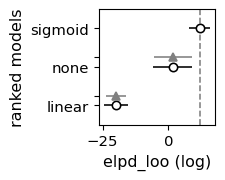

In [24]:
fig, ax = plt.subplots(figsize=(1.5, 1.5))
comparison = az.compare(trace_dict)
az.plot_compare(comparison, ax=ax, legend=False, title=False)
fig.savefig(f'figures/model_selection/loo_pandemic_fatigue_pair.png', bbox_inches='tight')
fig.savefig(f'figures/model_selection/loo_pandemic_fatigue_pair.pdf', bbox_inches='tight')

In [ ]:
# # compare plot with subplot for each indicator comibination, comparing the linear and sigmoid models
# nrows = 3
# ncols = 5
# for ic in ['loo', 'waic']:
#     fig, axs = plt.subplots(nrows, ncols, figsize=(10, 5))
#     axs = axs.flatten()
#     for i in range(len(all_indicator_combinations)):
#         keys = [key_dict[name][i] for name in key_dict.keys()]
#         # split key-string at ', '
#         keys_separate = [key.split(', ') for key in keys]
#         axs[i].set_title(keys_separate[0][1], fontsize=12)
#         traces = {}
#         for j in range(len(keys)):
#             strings = keys_separate[j]
#             key = keys[j]
#             traces[strings[0]] = trace_dict[key]
#         comparison = az.compare(traces, ic=ic)
#         az.plot_compare(comparison, ax=axs[i], legend=False, title=False)
#         axs[i].set_ylabel('')
#         if 15 - i > ncols:
#             axs[i].set_xlabel('')
#     # add horizontal padding between subplots
#     fig.subplots_adjust(wspace=0.8, hspace=0.5)
#     # save figure
#     fig.savefig(f'figures/model_selection/{ic}_pandemic_fatigue_pair.png', bbox_inches='tight')
#     fig.savefig(f'figures/model_selection/{ic}_pandemic_fatigue_pair.pdf', bbox_inches='tight')

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/

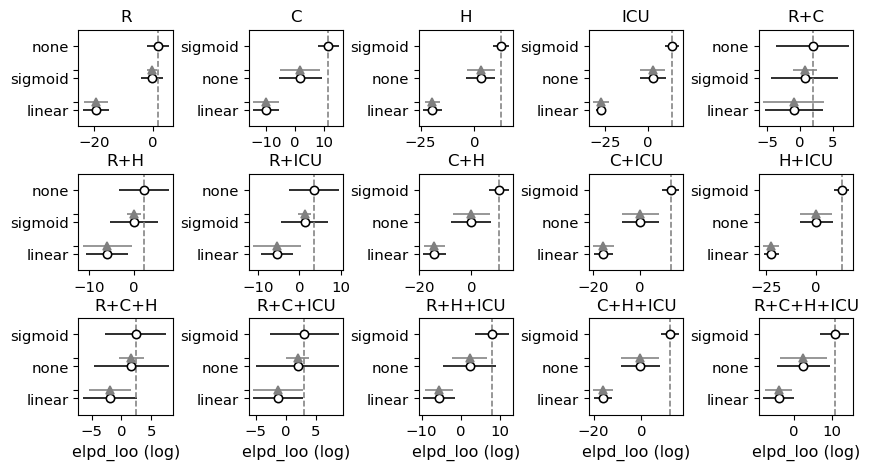

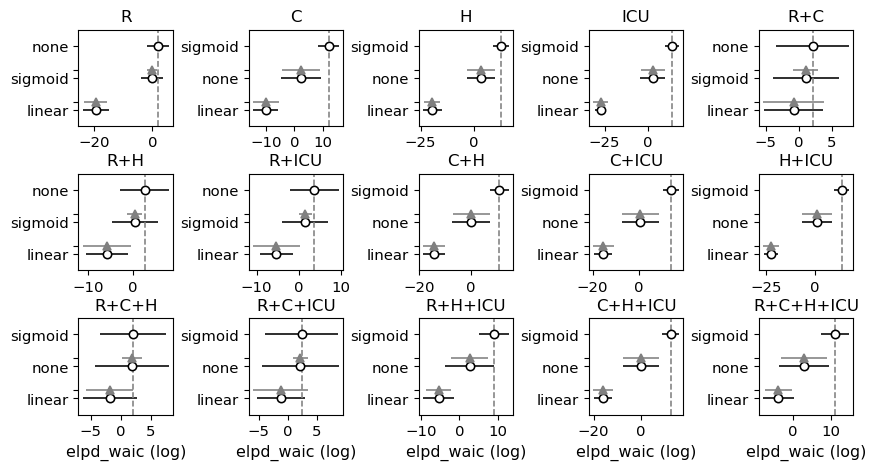

In [5]:
# compare plot with subplot for each indicator comibination, comparing the linear and sigmoid models
nrows = 3
ncols = 5
for ic in ['loo', 'waic']:
    fig, axs = plt.subplots(nrows, ncols, figsize=(10, 5))
    axs = axs.flatten()
    for i in range(len(all_indicator_combinations)):
        keys = [key_dict[name][i] for name in key_dict.keys()]
        # split key-string at ', '
        keys_separate = [key.split(', ') for key in keys]
        axs[i].set_title(keys_separate[0][1], fontsize=12)
        traces = {}
        for j in range(len(keys)):
            strings = keys_separate[j]
            key = keys[j]
            traces[strings[0]] = trace_dict[key]
        comparison = az.compare(traces, ic=ic)
        az.plot_compare(comparison, ax=axs[i], legend=False, title=False)
        axs[i].set_ylabel('')
        if 15 - i > ncols:
            axs[i].set_xlabel('')
    # add horizontal padding between subplots
    fig.subplots_adjust(wspace=0.8, hspace=0.5)
    # save figure
    fig.savefig(f'figures/model_selection/{ic}_pandemic_fatigue_pair.png', bbox_inches='tight')
    fig.savefig(f'figures/model_selection/{ic}_pandemic_fatigue_pair.pdf', bbox_inches='tight')

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/

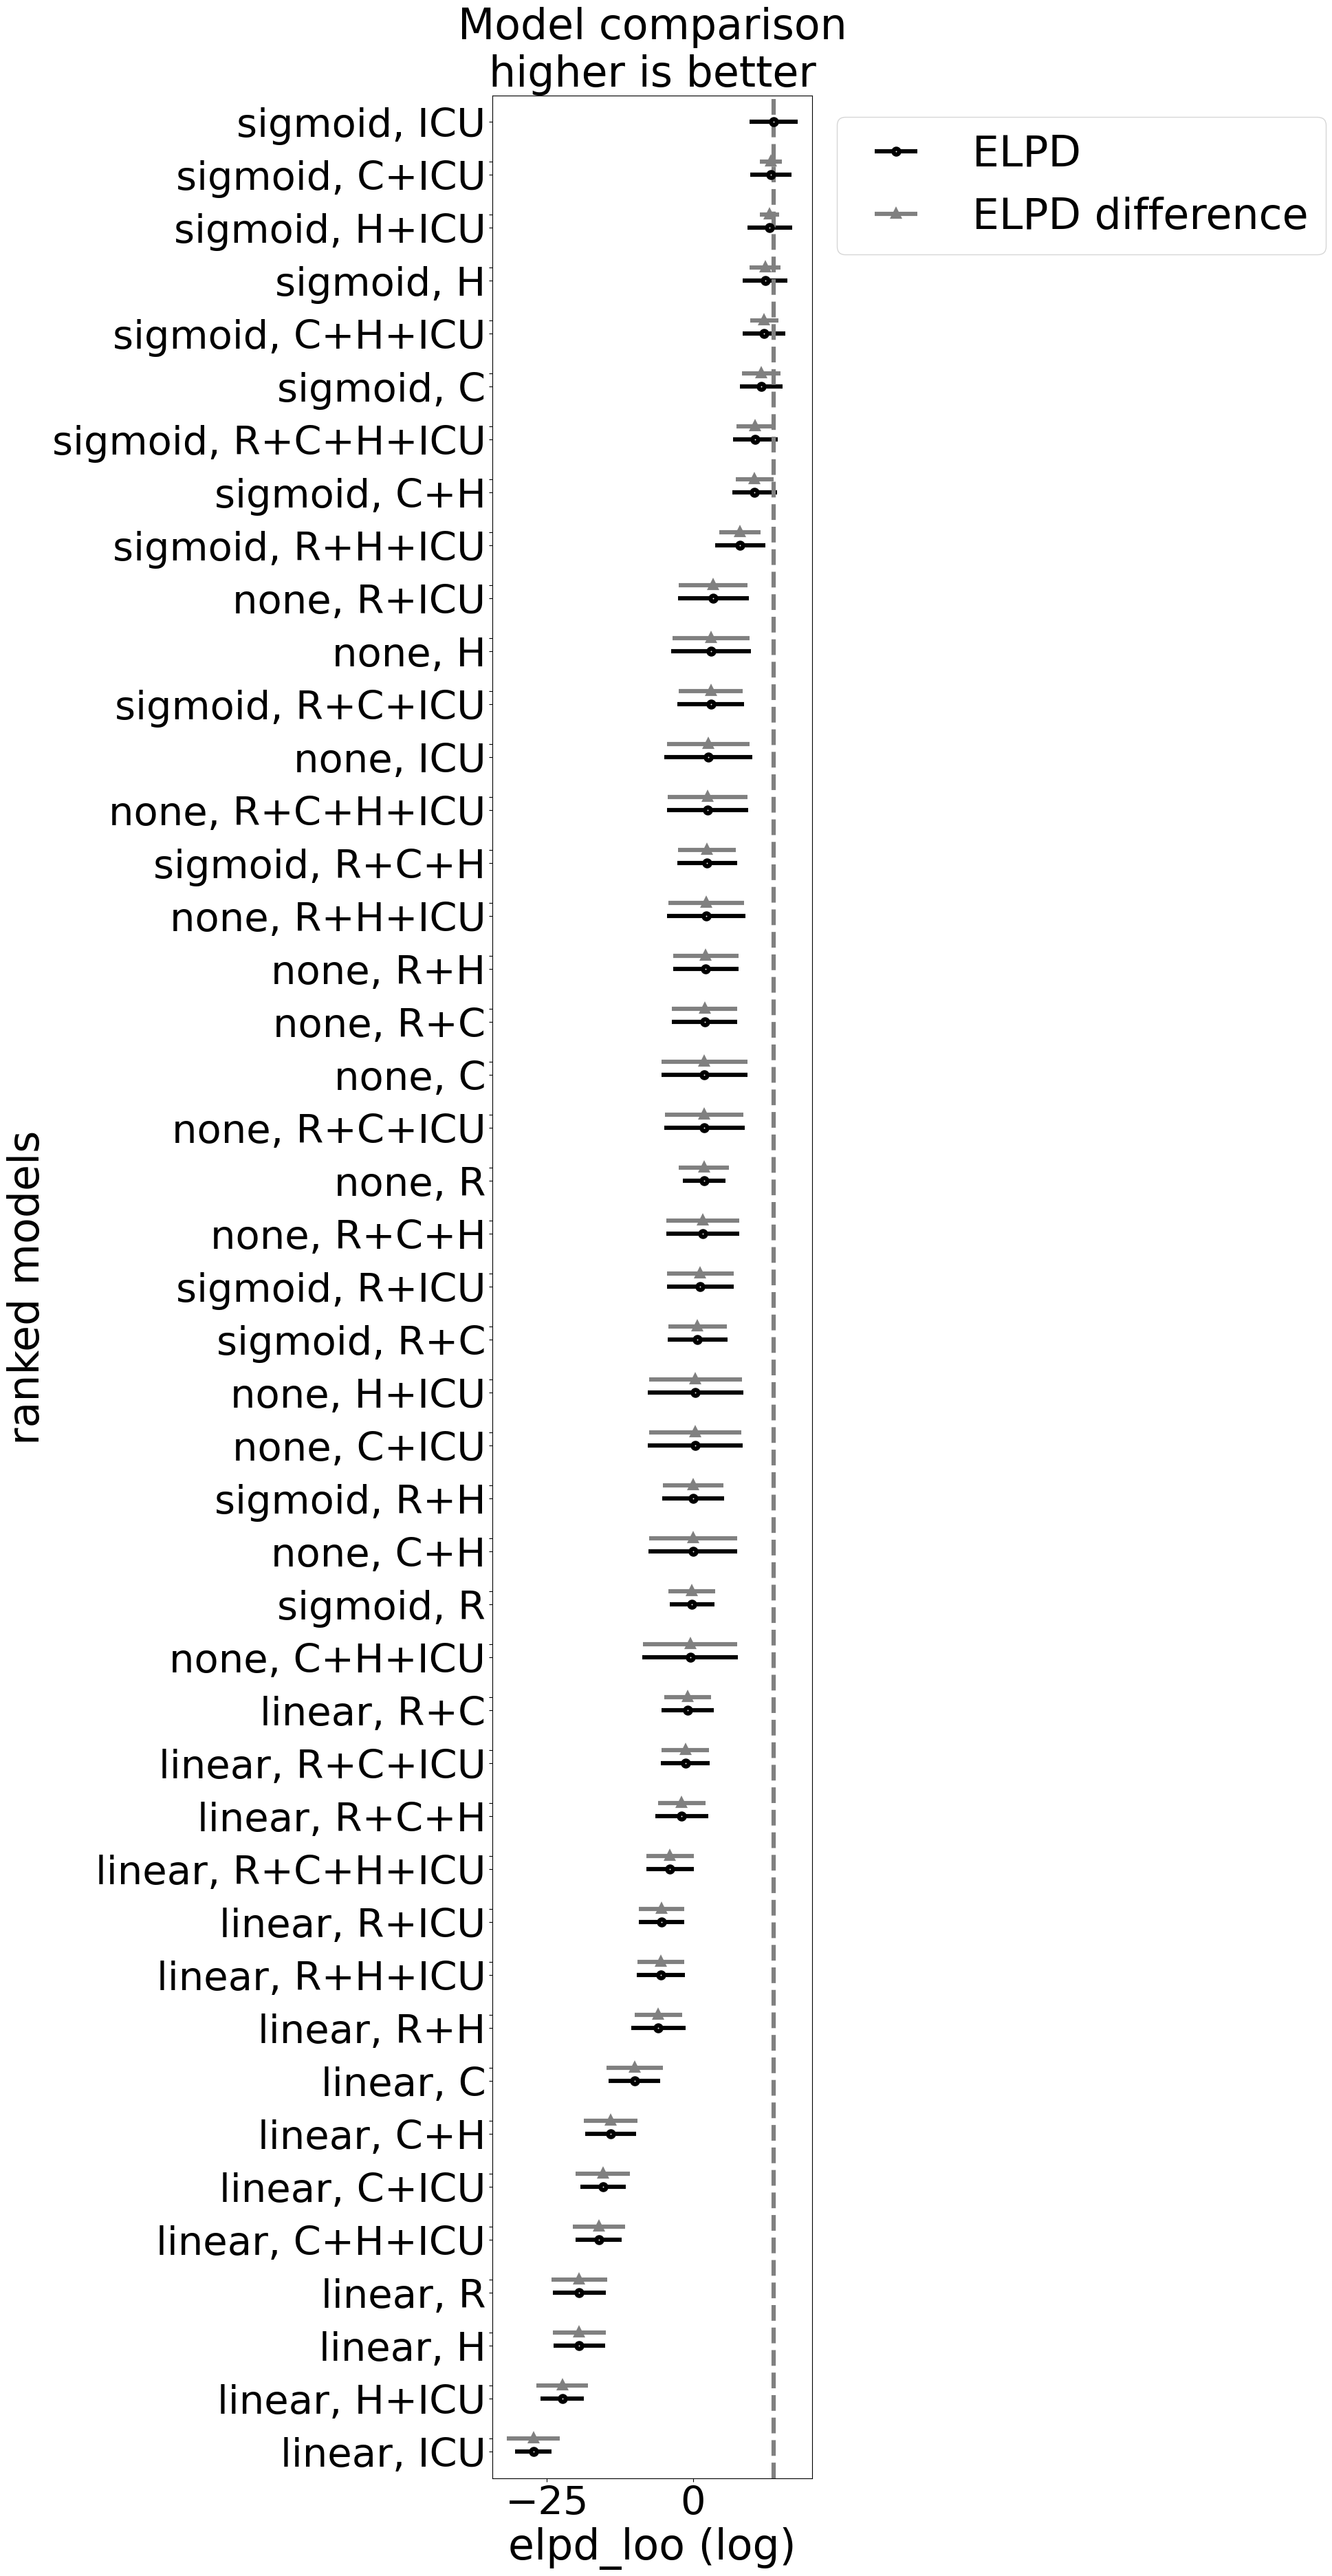

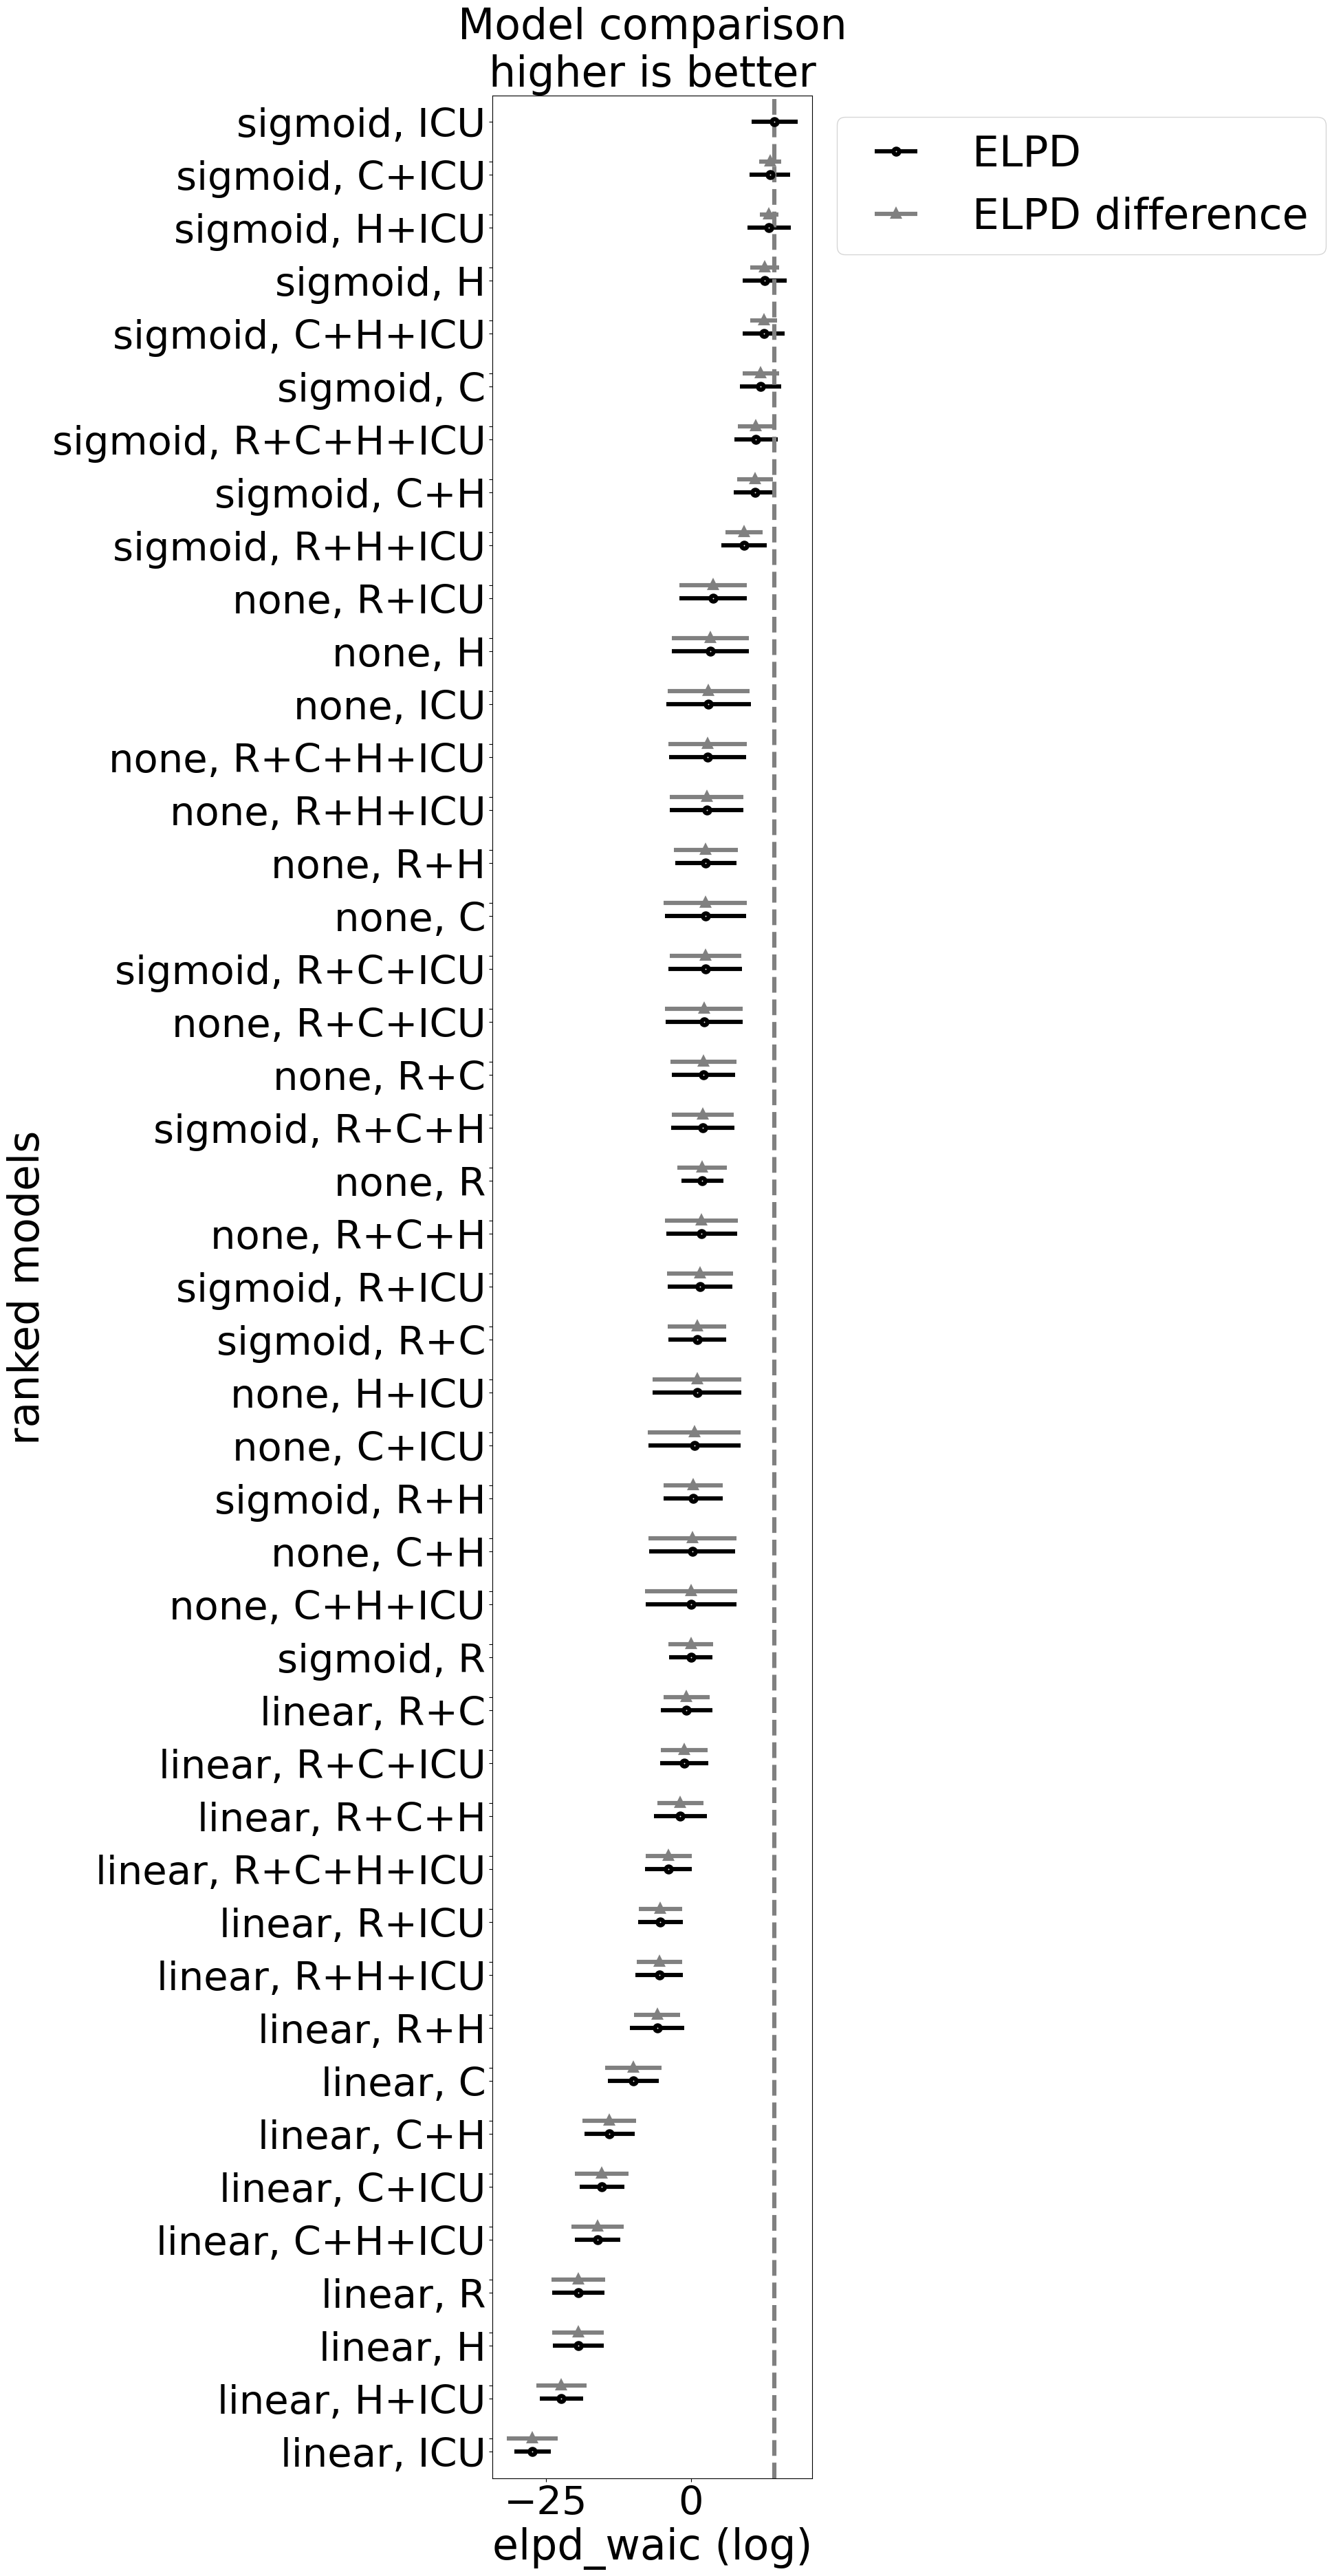

In [6]:
# model selection between all models in trace_dict
ics = ["loo", "waic"]
for ic in ics:
    comparison = az.compare(trace_dict, ic=ic)
    plot_result = az.plot_compare(comparison)
    # save plot
    plot_result.figure.savefig(f"figures/model_selection/{ic}_compare_pandemic_fatigue_all.png", bbox_inches="tight")

## Weather

In [4]:
# names = ["none", 
#          "precipitation", "temperature", "both"]
# labels = ["no weather", 
#           "precipitation", "temperature", "both"]
# # create empty dictionary with all indicator combinations as keys
# trace_dict = {}
# key_dict = {}

# # generate dictionary of all traces
# for i in range(len(names)):
#     name = names[i]
#     label = labels[i]
#     key_dict[label] = []
#     for indicators in all_indicator_combinations:
#         indicator_tag = ""
#         key = ""
#         for indicator in indicators:
#             indicator_tag += indicator + "_"
#             key += indicator + "+"
#         indicator_tag = indicator_tag[:-1]
#         key = label + ", " + key[:-1]
#         key_dict[label].append(key)

#         trace_dict[key] = utils.load_trace(name, indicator_tag)

In [28]:
names = ["none", 
         "precipitation", "temperature", "both"]
labels = ["no weather", 
          "precipitation", "temperature", "both"]
# create empty dictionary with all indicator combinations as keys
trace_dict = {}
key_dict = {}

# generate dictionary of all traces
for i in range(len(names)):
    name = names[i]
    label = labels[i]
    key_dict[label] = []
    for indicators in ["H"]:
        indicator_tag = ""
        key = ""
        for indicator in indicators:
            indicator_tag += indicator + "_"
            key += indicator + "+"
        indicator_tag = indicator_tag[:-1]
        key = label
        key_dict[label].append(key)

        trace_dict[key] = utils.load_trace(name, indicator_tag)

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/

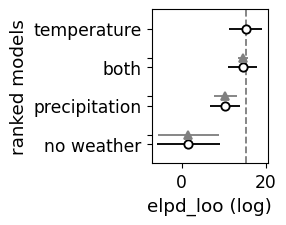

In [29]:
fig, ax = plt.subplots(figsize=(1.5, 2))
comparison = az.compare(trace_dict)
az.plot_compare(comparison, ax=ax, legend=False, title=False)
fig.savefig(f'figures/model_selection/loo_weather.png', bbox_inches='tight')
fig.savefig(f'figures/model_selection/loo_weather.pdf', bbox_inches='tight')

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/

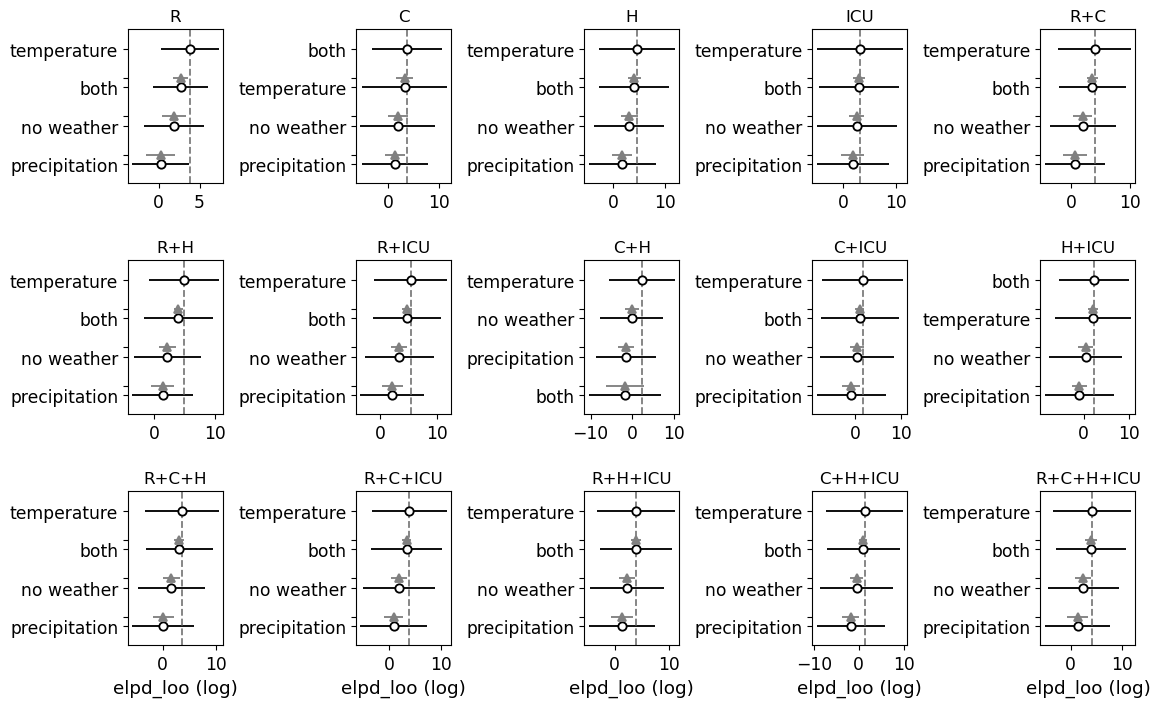

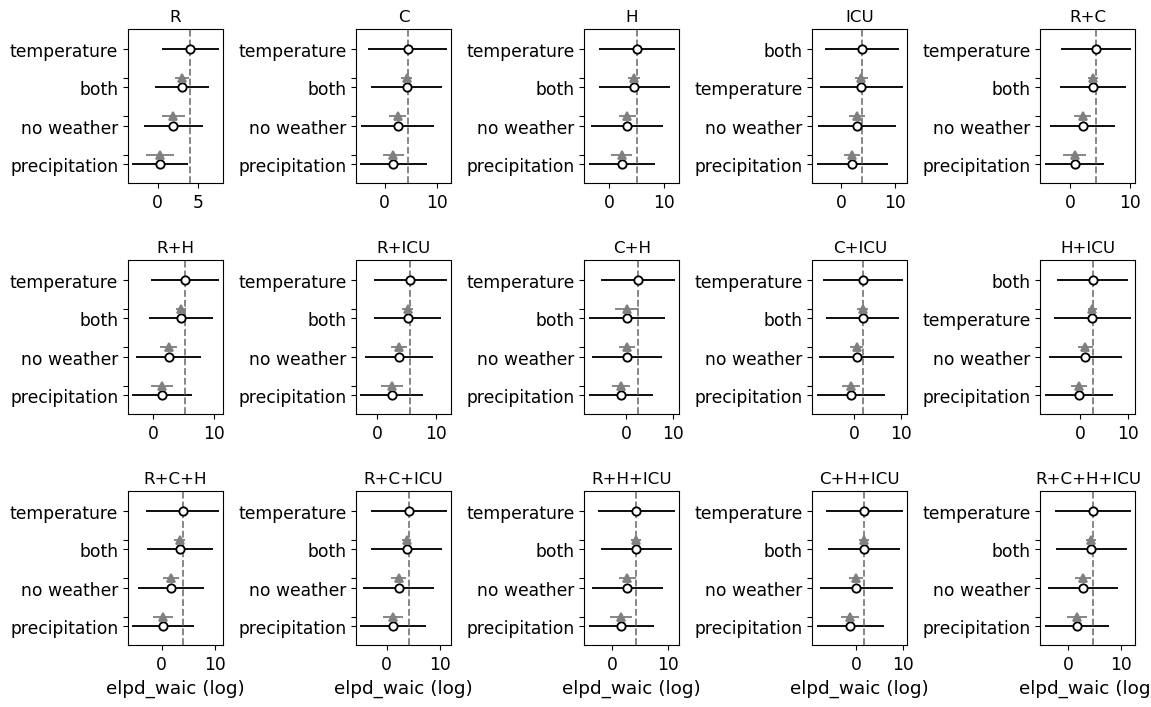

In [7]:
# # compare plot with subplot for each indicator comibination, comparing the linear and sigmoid models
# nrows = 3
# ncols = 5
# for ic in ['loo', 'waic']:
#     fig, axs = plt.subplots(nrows, ncols, figsize=(13, 8))
#     axs = axs.flatten()
#     for i in range(len(all_indicator_combinations)):
#         keys = [key_dict[name][i] for name in key_dict.keys()]
#         # split key-string at ', '
#         keys_separate = [key.split(', ') for key in keys]
#         axs[i].set_title(keys_separate[0][1], fontsize=12)
#         traces = {}
#         for j in range(len(keys)):
#             strings = keys_separate[j]
#             key = keys[j]
#             traces[strings[0]] = trace_dict[key]
#         comparison = az.compare(traces, ic=ic)
#         az.plot_compare(comparison, ax=axs[i], legend=False, title=False)
#         axs[i].set_ylabel('')
#         if 15 - i > ncols:
#             axs[i].set_xlabel('')
#     # add horizontal padding between subplots
#     fig.subplots_adjust(wspace=1.4, hspace=0.5)
#     # save figure
#     fig.savefig(f'figures/model_selection/{ic}_weather.png', bbox_inches='tight')
#     fig.savefig(f'figures/model_selection/{ic}_weather.pdf', bbox_inches='tight')